In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


c:\Users\Ryan\anaconda3\envs\pyp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import seaborn as sns

In [4]:
df_DA_US = df[(df['job_title_short']=='Data Analyst')&(df['job_country']=='United States')].copy()
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US.dropna(subset='salary_year_avg', inplace=True)

df_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median','count'])
df_salary = df_grouped.sort_values(by='median', ascending=False).head(10)
df_skills = df_grouped.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

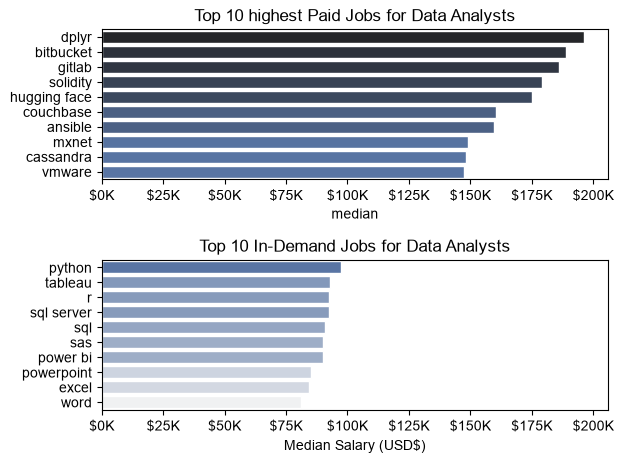

In [5]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')
sns.barplot(data=df_salary, x='median', y=df_salary.index, ax=ax[0], hue='median', palette='dark:b_r')
#df_salary[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].legend().remove()
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[0].set_title('Top 10 highest Paid Jobs for Data Analysts')
ax[0].set_ylabel('')

sns.barplot(data=df_skills, x='median', y=df_skills.index, ax=ax[1], hue='median', palette='light:b')
#df_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].legend().remove()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[1].set_title('Top 10 In-Demand Jobs for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD$)')

fig.tight_layout()

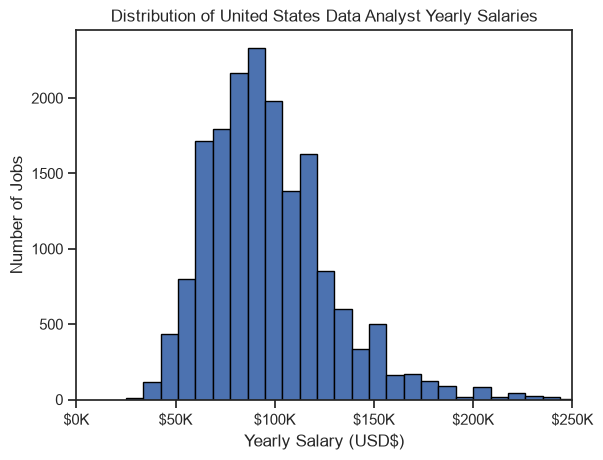

In [6]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.ylabel('Number of Jobs')
plt.xlabel('Yearly Salary (USD$)')
plt.show()

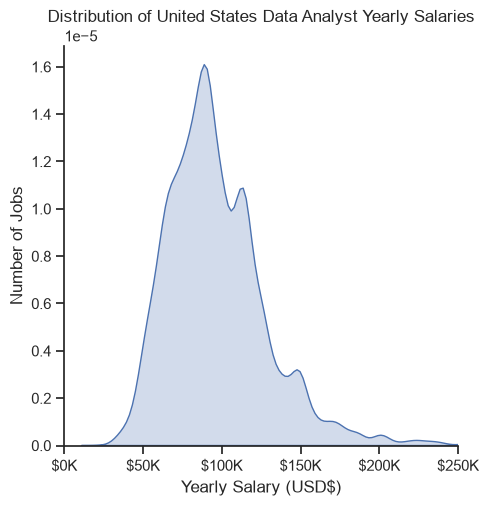

In [7]:
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.ylabel('Number of Jobs')
plt.xlabel('Yearly Salary (USD$)')
plt.show()

C:\Users\Ryan\AppData\Local\Temp\ipykernel_24928\133035385.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False)


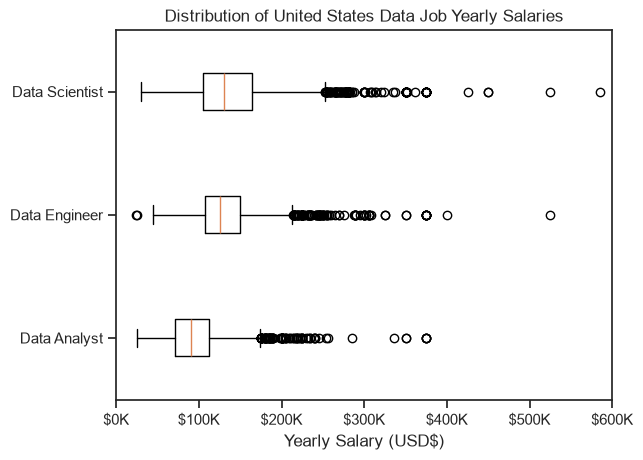

In [8]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US.dropna(subset='salary_year_avg', inplace=True)
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Distribution of United States Data Job Yearly Salaries')
plt.xlabel('Yearly Salary (USD$)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

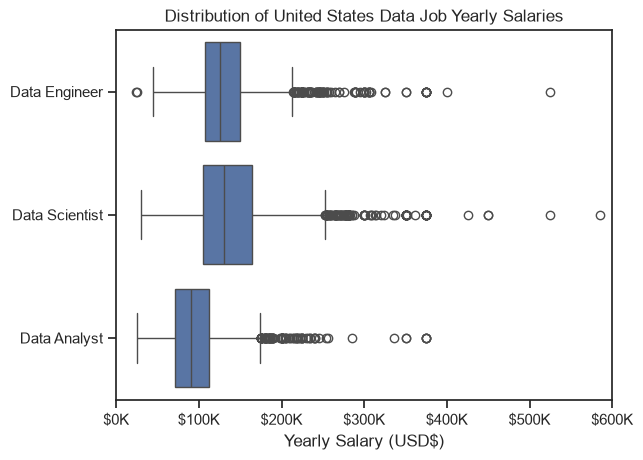

In [16]:
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')
plt.title('Distribution of United States Data Job Yearly Salaries')
plt.xlabel('Yearly Salary (USD$)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()